# Nghiên cứu dataflow UrbanSound8K -> 1D-CNN

Notebook này ghi **dataflow** (WAV → tensor 1D-CNN) **và chốt hướng nghiên cứu sau khảo sát**.

## Câu hỏi ban đầu (dataflow)
File WAV trong `UrbanSound8K` biến thành input 1D-CNN như thế nào, channel/tensor trông ra sao, cấu hình frame nào hợp lý.

## Câu hỏi đã chốt sau khảo sát (2026-07)
Trên protocol **source-safe**, model tốt nhất hiện tại (`kv260_audio_net_ds1d` full-clip, **no-teacher**) vẫn kẹt ở **representation / confusion texture** (nhầm class có vân âm thanh–nguồn ghi giống nhau).
**Hướng branch này:** không mở thêm kiến trúc model mới, **không dùng teacher/KD**; dùng đúng model tốt nhất để giải bài toán thực tế (source generalization / texture confusion).

Nguồn data audit: `data/UrbanSound8K_on_server.tar.gz` (hoặc archive tương đương 8732 clip).

Notebook có các hình paper-style (dataflow):
- Figure 1: waveform và frame overlap 50%
- Figure 2 / 2b: kiến trúc Abdoli 16k và TCAM local + verify shape
- Figure 3: phổ filter reference


## Tóm tắt điều hành (đã chốt)

### Dataflow (phần đầu notebook)
- Archive: **8732** WAV, **10** class, **10** fold.
- Raw waveform 1D-CNN: `[batch, 1, samples]`; full-clip chuẩn research: mono 16 kHz, **4 s → `[1, 64000]`**.
- Cần phân biệt: channel audio (mono) vs channel feature sau Conv; frame policy (8000/16000) vs full-clip.

### Model tốt nhất sau khảo sát (baseline khóa)
| Hạng mục | Giá trị |
|---|---|
| Model | `kv260_audio_net_ds1d` |
| Input | full-clip waveform 64 000 samples (~4 s @ 16 kHz), 1 frame/clip |
| Pool | pyramid avg+max, bins `[1,2,4]` |
| Params | **~101.7k** (101 674 có bias) |
| MAC/clip | **~61.9M** (budget KV260 ≤300k params / ≤300M MAC) |
| Train | Mixup + EMA + label smoothing + class weight; **không teacher, không KD** |
| Protocol chuẩn | `source_group_8_1_1` + `fsid_classid_balanced_v1`, overlap source train↔test = **0** |

### Kết quả headline đã đạt (fold 1, no-teacher)
| Nguồn | Best-val test | Ensemble / final (ghi rõ) |
|---|---:|---:|
| Local full-clip (mốc docs trước) | ~79.08–79.43% | ensemble **~79.89%** |
| Server 3090 push `4ac734f` (`results/server3090-notacher-f1`) | **76.90%** | ensemble **75.40%**; final-cycle **78.62%** |

Số **~79.6–79.9%** thường là **mốc local ensemble**, không đồng nhất với mọi metric trên server. Report luôn kèm tên metric.

### Quyết định branch (không đổi)
1. **Khóa** model `kv260_audio_net_ds1d` full-clip làm baseline triển khai nghiên cứu tiếp.
2. **Không** mở thêm hướng thực nghiệm kiến trúc model mới trên branch này.
3. **Không** dùng model teacher / distillation trên branch này.
4. Bài toán còn lại: **Representation / confusion texture + source generalization** (giải trên đúng model đã khóa).


## Bối cảnh & phương pháp

Notebook này không train model. Nó xuất và hiển thị dataflow để nhìn rõ dữ liệu vào 1D-CNN:

1. Đọc metadata và WAV trực tiếp từ archive gốc.
2. Chọn mẫu đại diện theo mỗi class: first, shortest, median-duration, longest.
3. Decode waveform bằng `ffmpeg` để xử lý được nhiều kiểu WAV trong UrbanSound8K.
4. Xuất các version quan sát ra `dataflow_exports/urban8k_1dcnn_from_archive`.
5. Hiển thị channel native, mono 16 kHz, clip tensor 4 s, frame strip, và pseudo feature channels.

Giả định chính: mục tiêu benchmark là UrbanSound8K 10 class official; không thêm `rail_vehicle`.

In [1]:
from pathlib import Path
import csv
import json
import subprocess
import sys

PROJECT_ROOT = Path(r"D:\Research\Research_Development_System\5_Thesis_Optimization_Guides\1_ai_accelerator_sound")
ARCHIVE_PATH = PROJECT_ROOT / "data" / "UrbanSound8K_on_server.tar.gz"
OUTPUT_DIR = PROJECT_ROOT / "dataflow_exports" / "urban8k_1dcnn_from_archive"
EXPORTER = PROJECT_ROOT / "tools" / "export_urbansound8k_1dcnn_dataflow.py"
FIGURE_SCRIPT = PROJECT_ROOT / "tools" / "create_paper_style_1dcnn_figures.py"
TRAIN_FILE = PROJECT_ROOT / "train_tcam1dcnn.py"

print("Project:", PROJECT_ROOT)
print("Archive:", ARCHIVE_PATH)
print("Output:", OUTPUT_DIR)
print("Archive exists:", ARCHIVE_PATH.exists())
print("Exporter exists:", EXPORTER.exists())
print("Figure script exists:", FIGURE_SCRIPT.exists())
print("Train file exists:", TRAIN_FILE.exists())

Project: D:\Research\Research_Development_System\5_Thesis_Optimization_Guides\1_ai_accelerator_sound
Archive: D:\Research\Research_Development_System\5_Thesis_Optimization_Guides\1_ai_accelerator_sound\data\UrbanSound8K_on_server.tar.gz
Output: D:\Research\Research_Development_System\5_Thesis_Optimization_Guides\1_ai_accelerator_sound\dataflow_exports\urban8k_1dcnn_from_archive
Archive exists: True
Exporter exists: True
Figure script exists: True
Train file exists: True


## 1. Tạo hoặc dùng lại dataflow export

Cell này chỉ chạy exporter nếu chưa có `export_receipt.json`. Nếu muốn tạo lại từ đầu, xóa folder output hoặc chạy exporter riêng từ terminal.

In [2]:
receipt_path = OUTPUT_DIR / "export_receipt.json"
if not receipt_path.exists():
    cmd = [sys.executable, str(EXPORTER), "--archive", str(ARCHIVE_PATH), "--output", str(OUTPUT_DIR)]
    print("Running exporter:", " ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("Reusing existing export:", receipt_path)

receipt = json.loads(receipt_path.read_text(encoding="utf-8"))
receipt

Reusing existing export: D:\Research\Research_Development_System\5_Thesis_Optimization_Guides\1_ai_accelerator_sound\dataflow_exports\urban8k_1dcnn_from_archive\export_receipt.json


{'ok': True,
 'output_dir': 'D:\\Research\\Research_Development_System\\5_Thesis_Optimization_Guides\\1_ai_accelerator_sound\\dataflow_exports\\urban8k_1dcnn_from_archive',
 'archive_path': 'D:\\Research\\Research_Development_System\\5_Thesis_Optimization_Guides\\1_ai_accelerator_sound\\data\\UrbanSound8K_on_server.tar.gz',
 'metadata_rows': 8732,
 'selected_samples': 40,
 'frame_configs': {'tcam_8000_hop4000_fixed4s': {'frame_length': 8000,
   'hop': 4000,
   'mode': 'fixed_4s',
   'note': 'TCAM practical config: 0.5 s frames, 50% overlap, 15 frames per 4 s clip.'},
  'tcam_16000_hop4000_fixed4s': {'frame_length': 16000,
   'hop': 4000,
   'mode': 'fixed_4s',
   'note': 'TCAM higher-accuracy search config: 1.0 s frames, 75% overlap, heavier than 8000.'},
  'abdoli_16000_hop8000_duration_safe': {'frame_length': 16000,
   'hop': 8000,
   'mode': 'duration_safe',
   'note': 'Abdoli-style 1.0 s frames, 50% overlap, no fully silent 4 s tail frames.'}}}

## 1b. Tạo hoặc dùng lại hình paper-style

Cell này sinh các hình tổng quan giống paper từ dataflow export hiện có. Hình kiến trúc Abdoli được verify bằng công thức layer shape; hình TCAM local được verify bằng code hiện tại.

In [3]:
figure_manifest_path = OUTPUT_DIR / "figures" / "paper_style_figure_manifest.json"
if not figure_manifest_path.exists():
    cmd = [
        sys.executable,
        str(FIGURE_SCRIPT),
        "--output-dir",
        str(OUTPUT_DIR),
        "--train-file",
        str(TRAIN_FILE),
    ]
    print("Running figure script:", " ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("Reusing existing figure export:", figure_manifest_path)

figure_manifest = json.loads(figure_manifest_path.read_text(encoding="utf-8"))
figure_manifest

Reusing existing figure export: D:\Research\Research_Development_System\5_Thesis_Optimization_Guides\1_ai_accelerator_sound\dataflow_exports\urban8k_1dcnn_from_archive\figures\paper_style_figure_manifest.json


{'ok': True,
 'output_dir': 'D:\\Research\\Research_Development_System\\5_Thesis_Optimization_Guides\\1_ai_accelerator_sound\\dataflow_exports\\urban8k_1dcnn_from_archive',
 'figure_dir': 'D:\\Research\\Research_Development_System\\5_Thesis_Optimization_Guides\\1_ai_accelerator_sound\\dataflow_exports\\urban8k_1dcnn_from_archive\\figures',
 'figures': {'framing_overlap': {'figure': 'D:\\Research\\Research_Development_System\\5_Thesis_Optimization_Guides\\1_ai_accelerator_sound\\dataflow_exports\\urban8k_1dcnn_from_archive\\figures\\figure_1_framing_overlap_50pct.svg',
   'source_sample': '108041-9-0-11.wav',
   'source_class': 'street_music',
   'frame_s': '1.0s-2.0s',
   'frame_s_plus_1': '1.5s-2.5s',
   'overlap': '50%'},
  'abdoli_architecture': {'figure': 'D:\\Research\\Research_Development_System\\5_Thesis_Optimization_Guides\\1_ai_accelerator_sound\\dataflow_exports\\urban8k_1dcnn_from_archive\\figures\\figure_2_abdoli_1dcnn_architecture_16000.svg',
   'shape_table': 'D:\\Researc

## 2. Nạp các bảng tổng quan

Các bảng này là shape của benchmark và các frame policy chính. Chúng giúp nhìn trước rủi ro class imbalance và silent padding trước khi train.

In [4]:
def read_csv_rows(path):
    with Path(path).open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))

def html_table(rows, max_rows=20, title=None):
    try:
        from IPython.display import HTML, display
    except Exception:
        print(title or "")
        for row in rows[:max_rows]:
            print(row)
        return
    rows = rows[:max_rows]
    if not rows:
        display(HTML("<p>No rows</p>"))
        return
    columns = list(rows[0].keys())
    head = "".join(f"<th>{col}</th>" for col in columns)
    body = []
    for row in rows:
        body.append("<tr>" + "".join(f"<td>{row.get(col, '')}</td>" for col in columns) + "</tr>")
    caption = f"<h4>{title}</h4>" if title else ""
    display(HTML(caption + "<table><thead><tr>" + head + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"))

archive_profile = json.loads((OUTPUT_DIR / "archive_profile.json").read_text(encoding="utf-8"))
class_counts = read_csv_rows(OUTPUT_DIR / "class_counts.csv")
fold_counts = read_csv_rows(OUTPUT_DIR / "fold_counts.csv")
frame_policy = read_csv_rows(OUTPUT_DIR / "frame_policy_summary.csv")
frame_policy_by_class = read_csv_rows(OUTPUT_DIR / "frame_policy_by_class.csv")
selected_manifest = read_csv_rows(OUTPUT_DIR / "selected_samples_manifest.csv")

archive_profile

{'members': 8761,
 'wav': 8732,
 'csv': 1,
 'readme': 1,
 'fold_counts': {'fold1': 873,
  'fold10': 837,
  'fold2': 888,
  'fold3': 925,
  'fold4': 990,
  'fold5': 936,
  'fold6': 823,
  'fold7': 838,
  'fold8': 806,
  'fold9': 816},
 'standard_name_wav': 8732,
 'tascam_wav': 0,
 'archive_path': 'D:\\Research\\Research_Development_System\\5_Thesis_Optimization_Guides\\1_ai_accelerator_sound\\data\\UrbanSound8K_on_server.tar.gz',
 'archive_size_bytes': 6023741708,
 'metadata_rows': 8732,
 'class_count': 10,
 'fold_count': 10,
 'ffmpeg': 'D:\\portfolio\\SadTalker\\tools\\ffmpeg\\ffmpeg-8.0-essentials_build\\bin\\ffmpeg.EXE',
 'ffprobe': 'D:\\portfolio\\SadTalker\\tools\\ffmpeg\\ffmpeg-8.0-essentials_build\\bin\\ffprobe.EXE'}

In [5]:
html_table(class_counts, title="Số lượng mẫu theo class từ archive")
html_table(fold_counts, title="Số lượng mẫu theo fold từ archive")
html_table(frame_policy, title="Tổng quan frame policy")

classID,class,count
0,air_conditioner,1000
1,car_horn,429
2,children_playing,1000
3,dog_bark,1000
4,drilling,1000
5,engine_idling,1000
6,gun_shot,374
7,jackhammer,1000
8,siren,929
9,street_music,1000


fold,count
1,873
2,888
3,925
4,990
5,936
6,823
7,838
8,806
9,816
10,837


config,mode,frame_length,hop,clips,frames,full_frames,partial_padded_frames,silent_tail_frames,silent_tail_frame_rate,note
tcam_8000_hop4000_fixed4s,fixed_4s,8000,4000,8732,130980,116635,2720,11625,0.08875401,"TCAM practical config: 0.5 s frames, 50% overlap, 15 frames per 4 s clip."
tcam_16000_hop4000_fixed4s,fixed_4s,16000,4000,8732,113516,99648,4894,8974,0.07905493,"TCAM higher-accuracy search config: 1.0 s frames, 75% overlap, heavier than 8000."
abdoli_16000_hop8000_duration_safe,duration_safe,16000,8000,8732,54203,53747,456,0,0.0,"Abdoli-style 1.0 s frames, 50% overlap, no fully silent 4 s tail frames."


## 3. "Channel" trong 1D-CNN nghĩa là gì

Có hai loại channel cần phân biệt:

- Audio source channel: mono/stereo của file WAV gốc. Sau tiền xử lý cho raw 1D-CNN, ta thường downmix thành mono, nên input channel = 1.
- Feature channel: sau Conv1D, mỗi filter tạo ra một activation channel. Ví dụ input `[1, 8000]` qua 32 filters sẽ thành `[32, 8000]`. Đây không còn là left/right audio channel, mà là 32 tín hiệu đặc trưng một chiều theo thời gian.

Tensor convention trong PyTorch: `[batch, channels, length]`.

In [6]:
def conv1d_out_len(length, kernel, stride=1, padding=0, dilation=1):
    return (length + 2 * padding - dilation * (kernel - 1) - 1) // stride + 1

layers = [
    ("input", None, 1, None, None, 8000),
    ("conv1", 32, 32, 1, 15, None),
    ("tcam1", None, 32, None, None, None),
    ("conv2", 16, 32, 2, 7, None),
    ("tcam2", None, 32, None, None, None),
    ("conv3", 9, 64, 2, 4, None),
    ("tcam3", None, 64, None, None, None),
    ("conv4", 6, 64, 2, 2, None),
    ("tcam4", None, 64, None, None, None),
    ("conv5", 3, 128, 5, 1, None),
    ("tcam5", None, 128, None, None, None),
    ("conv6", 3, 128, 5, 1, None),
    ("tcam6", None, 128, None, None, None),
    ("conv7", 3, 256, 2, 1, None),
    ("global_average_pooling", None, 256, None, None, 1),
    ("classifier", None, 10, None, None, 1),
]

shape_rows = []
length = 8000
channels = 1
for name, kernel, out_channels, stride, padding, forced_len in layers:
    if kernel is not None:
        length = conv1d_out_len(length, kernel, stride=stride, padding=padding)
        channels = out_channels
    elif forced_len is not None:
        length = forced_len
        channels = out_channels
    else:
        channels = out_channels
    shape_rows.append({
        "layer": name,
        "channels": channels,
        "length": length,
        "tensor_shape_without_batch": f"[{channels}, {length}]",
    })

html_table(shape_rows, max_rows=30, title="Luồng shape TCAM1DCNN cho một frame 8000 samples")

layer,channels,length,tensor_shape_without_batch
input,1,8000,"[1, 8000]"
conv1,32,7999,"[32, 7999]"
tcam1,32,7999,"[32, 7999]"
conv2,32,3999,"[32, 3999]"
tcam2,32,3999,"[32, 3999]"
conv3,64,2000,"[64, 2000]"
tcam3,64,2000,"[64, 2000]"
conv4,64,1000,"[64, 1000]"
tcam4,64,1000,"[64, 1000]"
conv5,128,200,"[128, 200]"


## 4. Quan sát các mẫu đại diện

Mỗi sample folder có các version:

- `v0_original_from_archive.wav`
- `v1_native_channels.svg`: WAV gốc, native channels.
- `v2_mono_16k_normalized.svg`: signal 1D sau mono + resample + normalize.
- `v3_clip4s_tensor_1x64000.svg`: fixed 4 s tensor `[1, 64000]`.
- `v4_frames_*_strip.svg`: các frame đưa vào 1D-CNN.
- `v5_pseudo_feature_channels_after_1d_filters.svg`: minh họa cách một input channel thành nhiều feature channels sau filter 1D.

Pseudo feature channels không phải activation của model đã train; nó chỉ để nhìn trực quan logic Conv1D.

In [7]:
html_table(selected_manifest, max_rows=40, title="Các mẫu đại diện được chọn")

sample_key,selection_tag,classID,class,fold,slice_file_name,duration_csv_s,archive_member,native_sample_rate,native_channels,native_duration_s,codec_name,sample_dir
air_conditioner__first__127873-0-0-0,first,0,air_conditioner,1,127873-0-0-0.wav,2.04075,UrbanSound8K/audio/fold1/127873-0-0-0.wav,48000,1,2.04,pcm_s24le,samples/air_conditioner__first__127873-0-0-0
air_conditioner__longest__79089-0-0-106,longest,0,air_conditioner,9,79089-0-0-106.wav,4.0,UrbanSound8K/audio/fold9/79089-0-0-106.wav,44100,2,4.0,pcm_f32le,samples/air_conditioner__longest__79089-0-0-106
air_conditioner__median_duration__178686-0-0-39,median_duration,0,air_conditioner,5,178686-0-0-39.wav,4.0,UrbanSound8K/audio/fold5/178686-0-0-39.wav,48000,2,4.0,pcm_s24le,samples/air_conditioner__median_duration__178686-0-0-39
air_conditioner__shortest__127873-0-0-0,shortest,0,air_conditioner,1,127873-0-0-0.wav,2.04075,UrbanSound8K/audio/fold1/127873-0-0-0.wav,48000,1,2.04,pcm_s24le,samples/air_conditioner__shortest__127873-0-0-0
car_horn__first__156194-1-0-0,first,1,car_horn,1,156194-1-0-0.wav,0.252086,UrbanSound8K/audio/fold1/156194-1-0-0.wav,44100,2,0.25,pcm_s16le,samples/car_horn__first__156194-1-0-0
car_horn__longest__128465-1-0-0,longest,1,car_horn,6,128465-1-0-0.wav,4.0,UrbanSound8K/audio/fold6/128465-1-0-0.wav,48000,1,4.0,pcm_s16le,samples/car_horn__longest__128465-1-0-0
car_horn__median_duration__187356-1-3-0,median_duration,1,car_horn,4,187356-1-3-0.wav,3.490051,UrbanSound8K/audio/fold4/187356-1-3-0.wav,96000,2,3.49,pcm_s24le,samples/car_horn__median_duration__187356-1-3-0
car_horn__shortest__87275-1-2-0,shortest,1,car_horn,1,87275-1-2-0.wav,0.054517,UrbanSound8K/audio/fold1/87275-1-2-0.wav,44100,2,0.05,pcm_s16le,samples/car_horn__shortest__87275-1-2-0
children_playing__first__105415-2-0-1,first,2,children_playing,1,105415-2-0-1.wav,4.0,UrbanSound8K/audio/fold1/105415-2-0-1.wav,48000,2,4.0,pcm_s16le,samples/children_playing__first__105415-2-0-1
children_playing__longest__170564-2-1-32,longest,2,children_playing,4,170564-2-1-32.wav,4.0,UrbanSound8K/audio/fold4/170564-2-1-32.wav,48000,2,4.0,pcm_s24le,samples/children_playing__longest__170564-2-1-32


In [8]:
def sample_by(class_name, selection_tag):
    for row in selected_manifest:
        if row["class"] == class_name and row["selection_tag"] == selection_tag:
            return row
    raise KeyError((class_name, selection_tag))

samples_to_view = [
    sample_by("gun_shot", "shortest"),
    sample_by("car_horn", "shortest"),
    sample_by("street_music", "first"),
]

[(row["class"], row["selection_tag"], row["slice_file_name"], row["sample_dir"]) for row in samples_to_view]

[('gun_shot',
  'shortest',
  '76091-6-4-0.wav',
  'samples/gun_shot__shortest__76091-6-4-0'),
 ('car_horn',
  'shortest',
  '87275-1-2-0.wav',
  'samples/car_horn__shortest__87275-1-2-0'),
 ('street_music',
  'first',
  '108041-9-0-11.wav',
  'samples/street_music__first__108041-9-0-11')]

### gun_shot / shortest / 76091-6-4-0.wav - v1 channel gốc

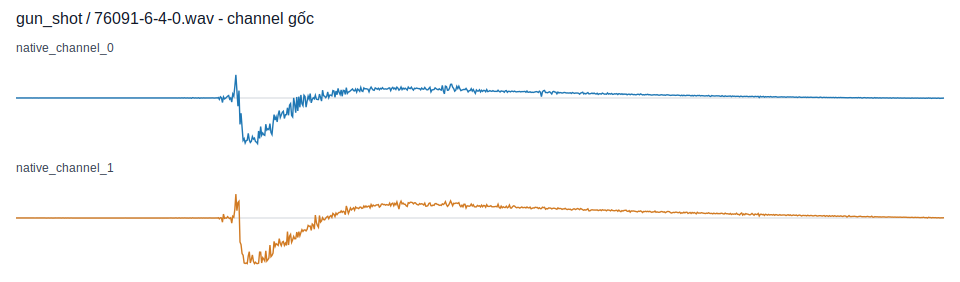

### gun_shot / shortest / 76091-6-4-0.wav - v2 mono 16 kHz

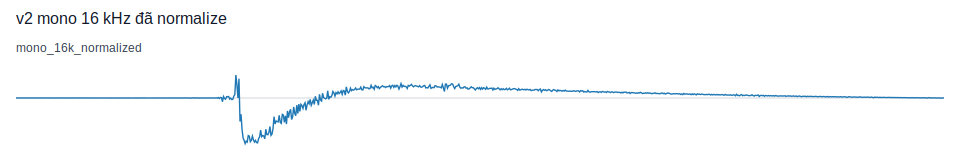

### gun_shot / shortest / 76091-6-4-0.wav - v3 tensor [1, 64000]

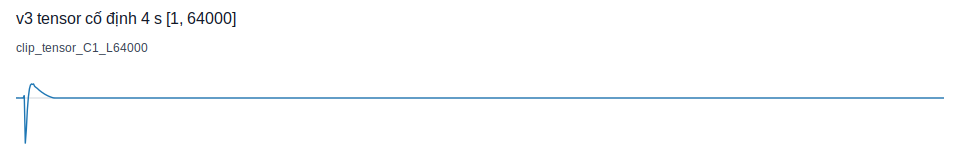

### gun_shot / shortest / 76091-6-4-0.wav - v4 frames [1, 8000]

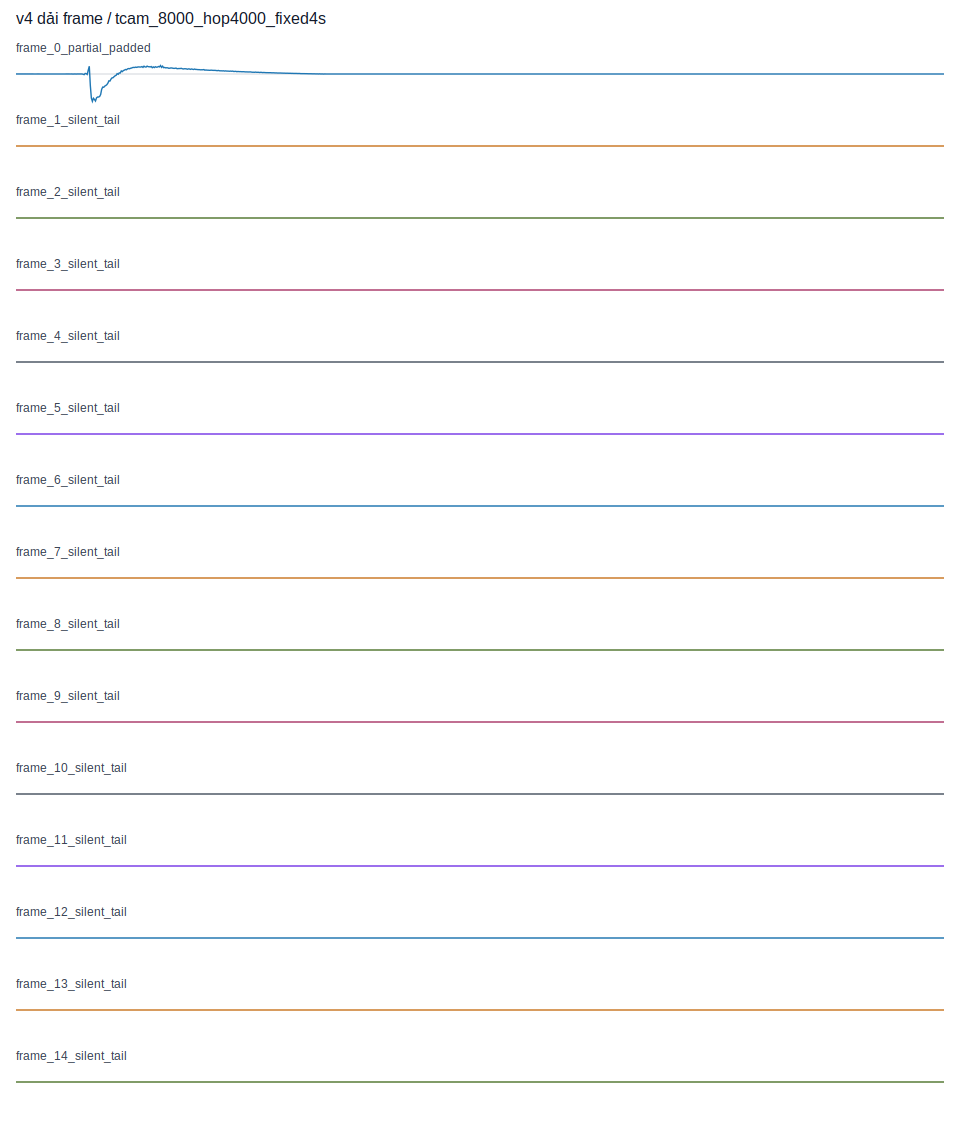

### gun_shot / shortest / 76091-6-4-0.wav - v5 pseudo channels Conv1D

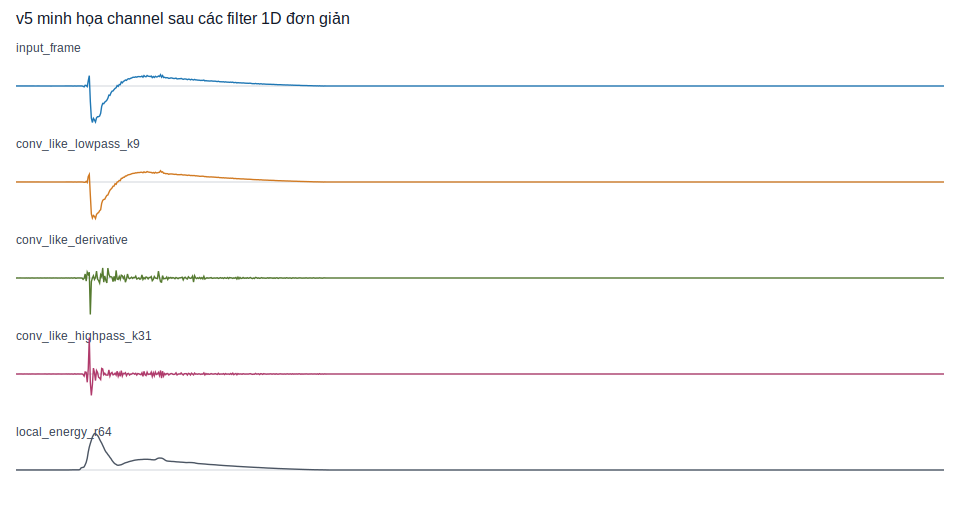

### car_horn / shortest / 87275-1-2-0.wav - v1 channel gốc

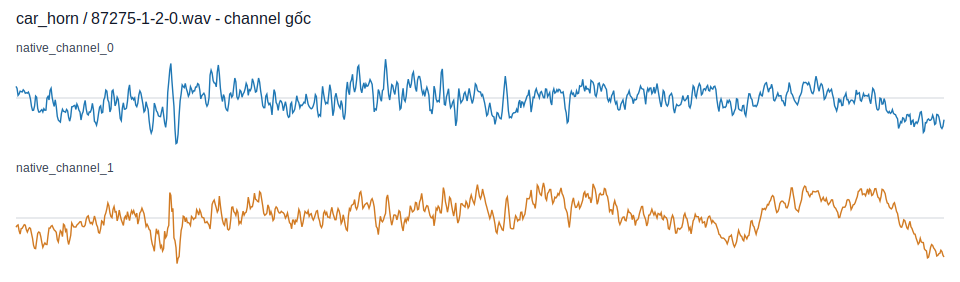

### car_horn / shortest / 87275-1-2-0.wav - v2 mono 16 kHz

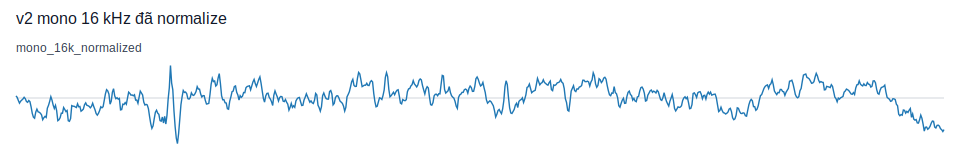

### car_horn / shortest / 87275-1-2-0.wav - v3 tensor [1, 64000]

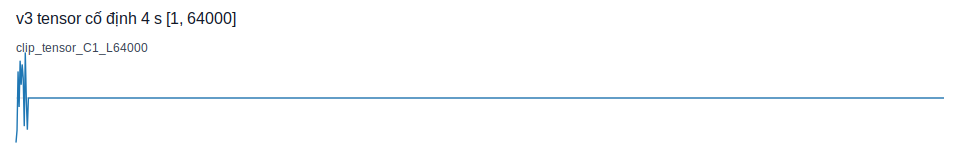

### car_horn / shortest / 87275-1-2-0.wav - v4 frames [1, 8000]

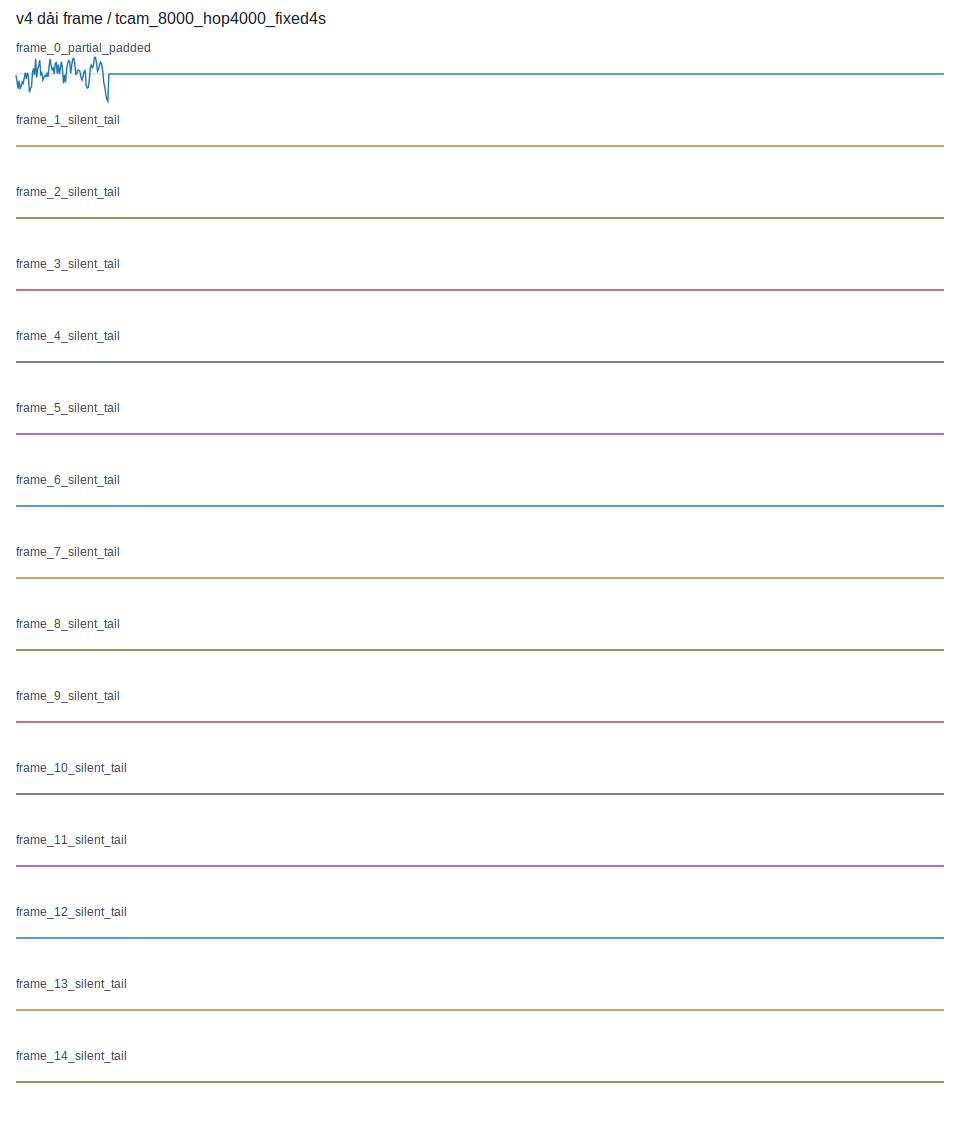

### car_horn / shortest / 87275-1-2-0.wav - v5 pseudo channels Conv1D

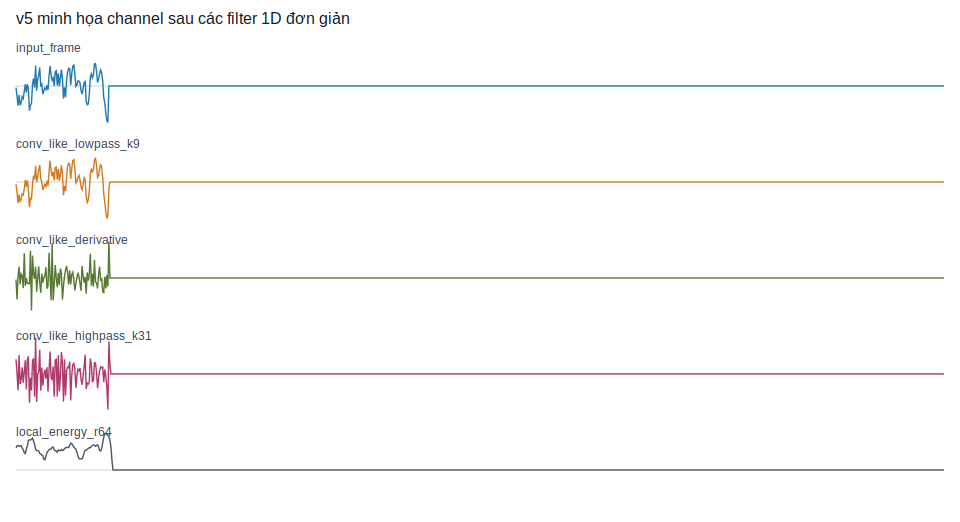

### street_music / first / 108041-9-0-11.wav - v1 channel gốc

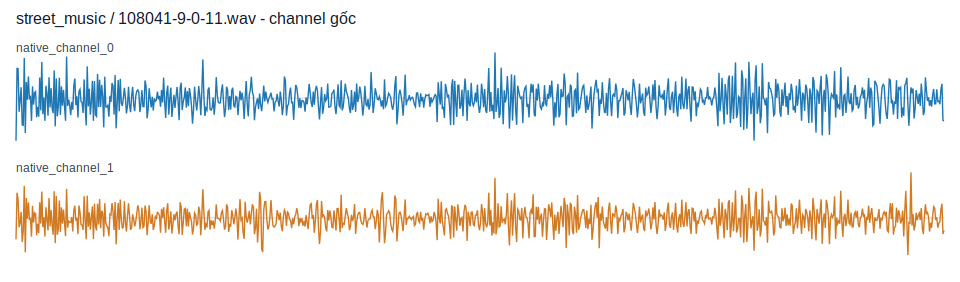

### street_music / first / 108041-9-0-11.wav - v2 mono 16 kHz

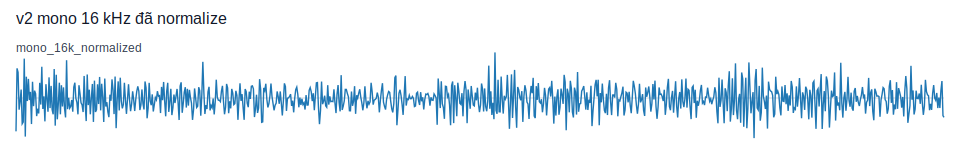

### street_music / first / 108041-9-0-11.wav - v3 tensor [1, 64000]

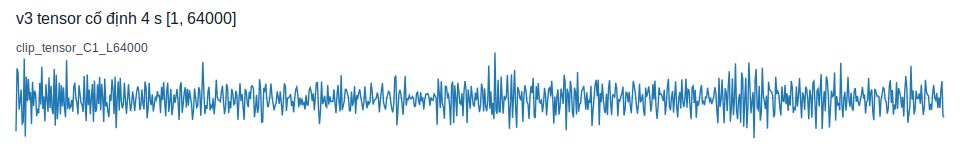

### street_music / first / 108041-9-0-11.wav - v4 frames [1, 8000]

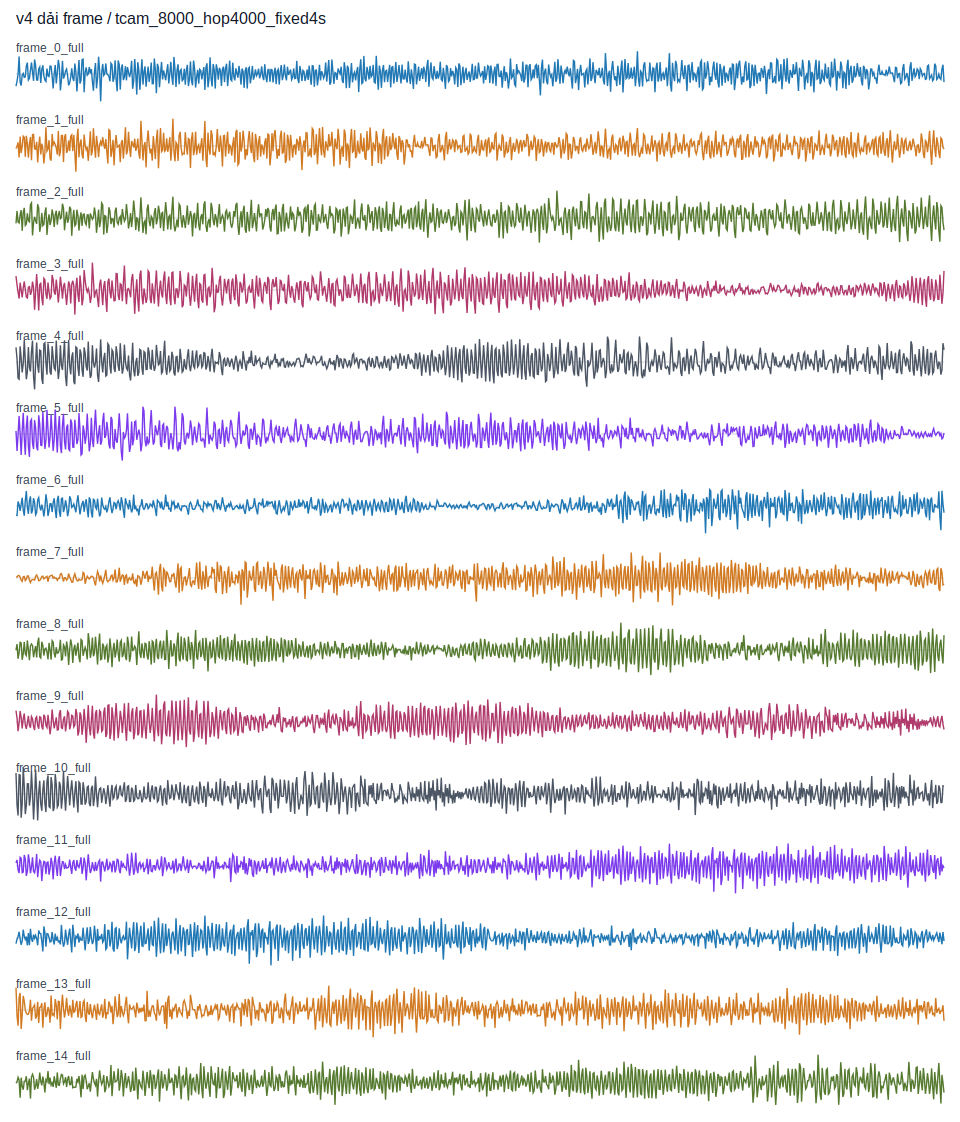

### street_music / first / 108041-9-0-11.wav - v5 pseudo channels Conv1D

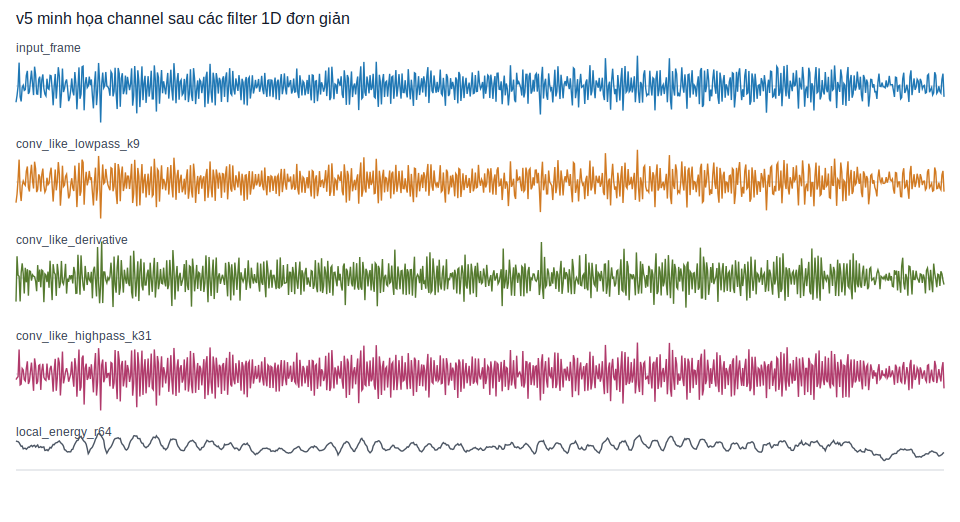

In [9]:
def display_svg(path, title=None):
    path = Path(path)
    try:
        from IPython.display import SVG, Markdown, display
        if title:
            display(Markdown(f"### {title}"))
        display(SVG(filename=str(path)))
    except Exception:
        print(title or path.name)
        print(path)

for row in samples_to_view:
    sample_dir = OUTPUT_DIR / row["sample_dir"]
    title_prefix = f"{row['class']} / {row['selection_tag']} / {row['slice_file_name']}"
    display_svg(sample_dir / "v1_native_channels.svg", title_prefix + " - v1 channel gốc")
    display_svg(sample_dir / "v2_mono_16k_normalized.svg", title_prefix + " - v2 mono 16 kHz")
    display_svg(sample_dir / "v3_clip4s_tensor_1x64000.svg", title_prefix + " - v3 tensor [1, 64000]")
    display_svg(sample_dir / "v4_frames_tcam_8000_hop4000_fixed4s_strip.svg", title_prefix + " - v4 frames [1, 8000]")
    display_svg(sample_dir / "v5_pseudo_feature_channels_after_1d_filters.svg", title_prefix + " - v5 pseudo channels Conv1D")

## 5. Hình paper-style và verify kiến trúc

Các hình dưới đây giải quyết đúng khoảng thiếu của lần trước:

- Figure 1 cho thấy frame overlap từ waveform thật sau mono 16 kHz.
- Figure 2 tái dựng kiến trúc Abdoli 16,000 input giống paper và kiểm tra từng output shape.
- Figure 2b kiểm tra kiến trúc TCAM local từ `train_tcam1dcnn.py`, không chỉ dựa vào comment.
- Figure 3 là phổ filter reference để hiểu cách Conv1D học band/time filter. Muốn có phổ filter đã học thật, cần checkpoint từ một run chuẩn trên archive 10 class.

### Figure 1 - Framing overlap 50%

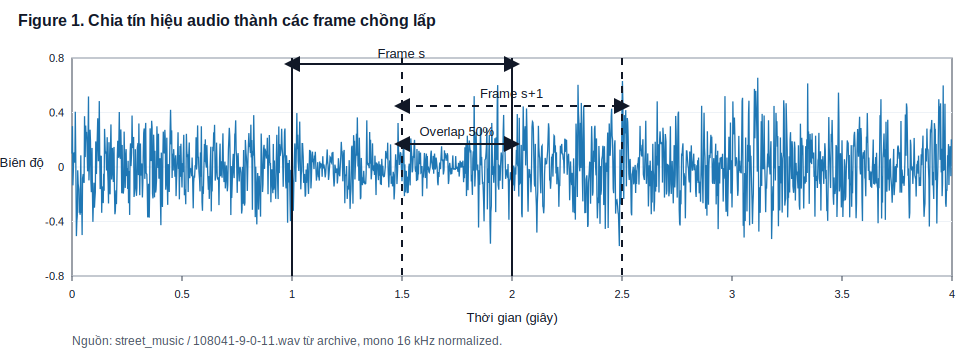

### Figure 2 - Abdoli 1D-CNN 16,000 input

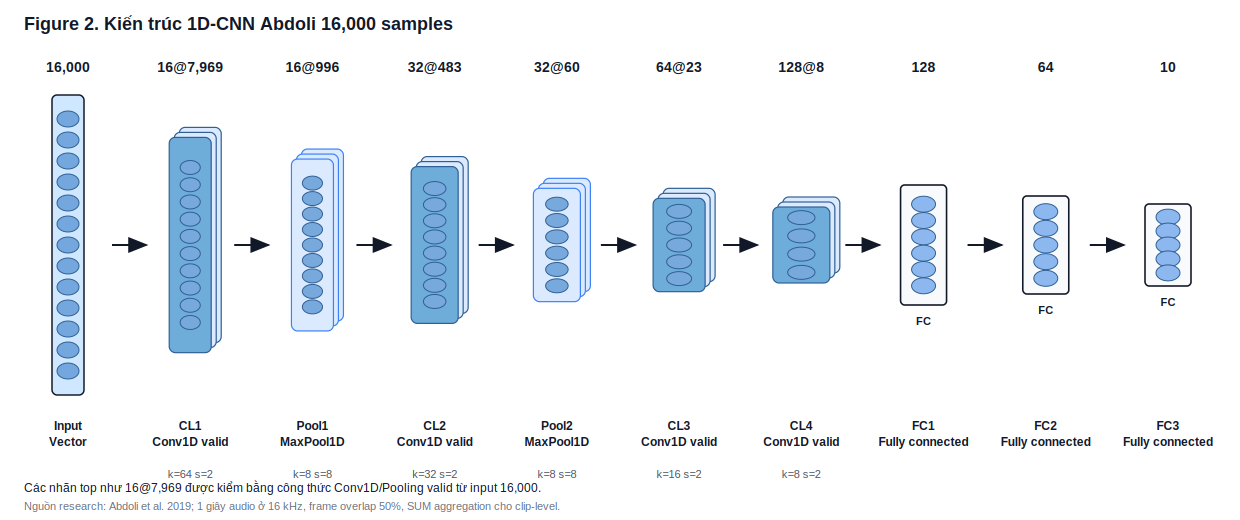

### Figure 2b - TCAM local shape từ code hiện tại

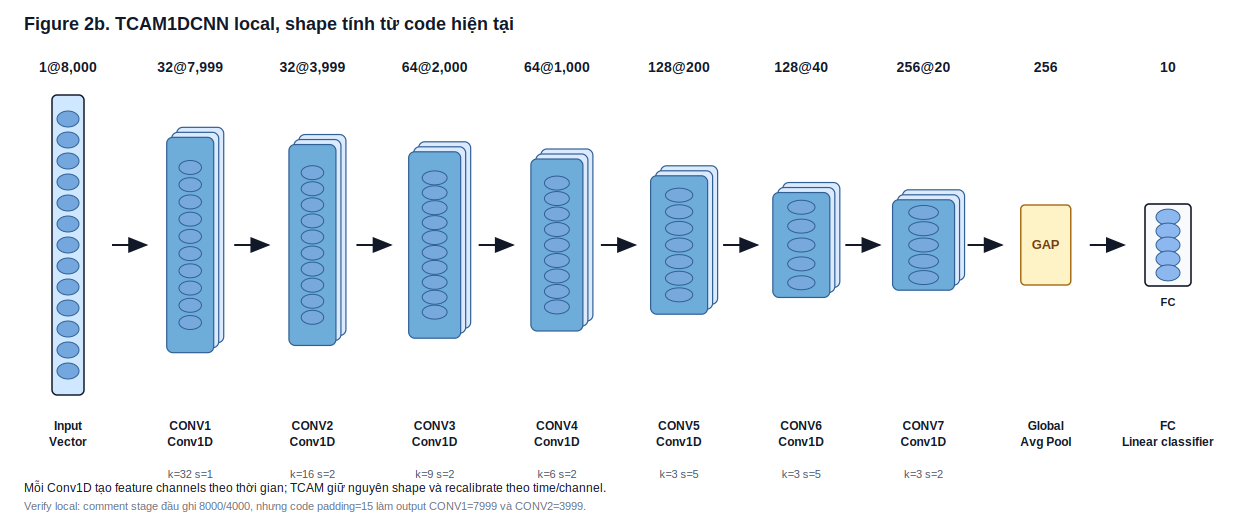

### Figure 3 - Phổ filter reference

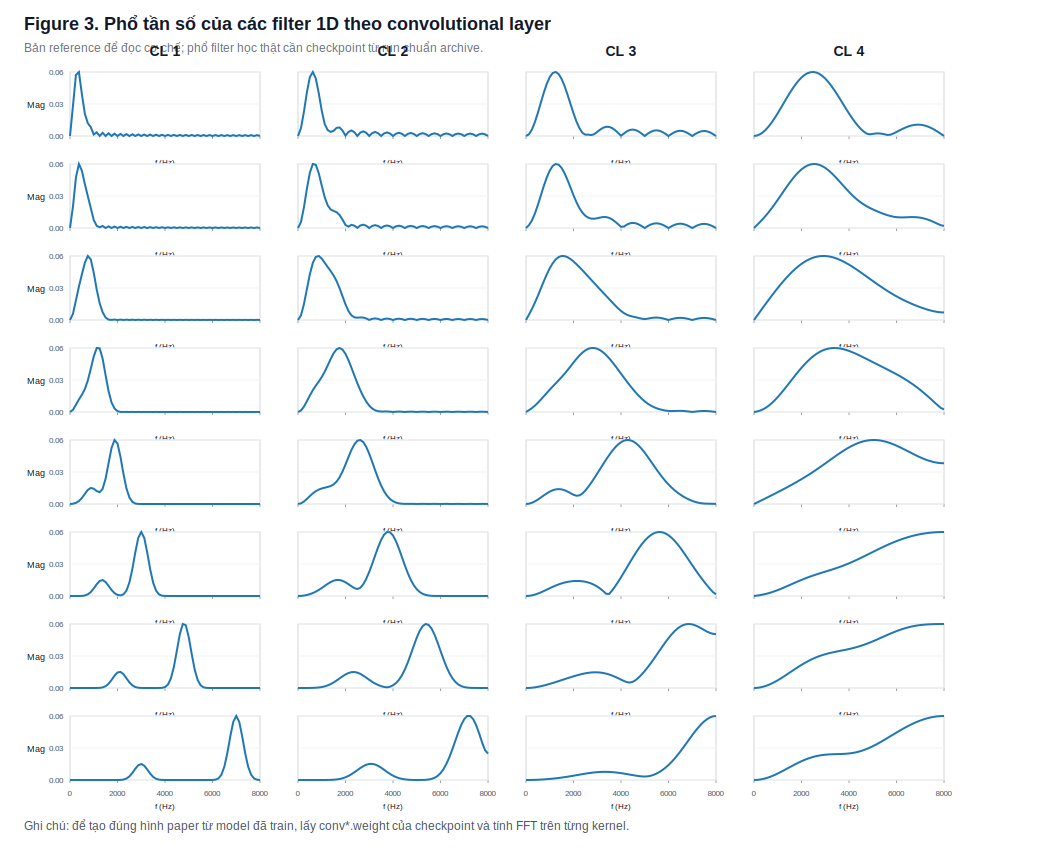

order,stage,operation,input_shape,kernel_or_units,stride,padding,output_channels,output_length,display_shape,params_no_bn,formula,verify
0,Input,raw waveform frame,,,,0,1,16000,"16,000",0,1 giây audio ở 16 kHz,source-aligned
1,CL1,Conv1D valid + ReLU,"[1, 16000]",64,2,0,16,7969,"16@7,969",1040,floor((L - 64)/2) + 1,match
2,Pool1,MaxPool1D,"[16, 7969]",8,8,0,16,996,16@996,0,floor((L - 8)/8) + 1,match
3,CL2,Conv1D valid + ReLU,"[16, 996]",32,2,0,32,483,32@483,16416,floor((L - 32)/2) + 1,match
4,Pool2,MaxPool1D,"[32, 483]",8,8,0,32,60,32@60,0,floor((L - 8)/8) + 1,match
5,CL3,Conv1D valid + ReLU,"[32, 60]",16,2,0,64,23,64@23,32832,floor((L - 16)/2) + 1,match
6,CL4,Conv1D valid + ReLU,"[64, 23]",8,2,0,128,8,128@8,65664,floor((L - 8)/2) + 1,match
7,FC1,Fully connected,1024,128,,,128,1,128,131200,in_units * out_units + out_units,match
8,FC2,Fully connected,128,64,,,64,1,64,8256,in_units * out_units + out_units,match
9,FC3,Fully connected,64,10,,,10,1,10,650,in_units * out_units + out_units,match


order,stage,operation,input_shape,kernel_or_units,stride,padding,output_channels,output_length,display_shape,params_no_bn,comment_expected_length,verify,formula
0,Input,raw waveform frame,,,,,1,8000,"1@8,000",0,,source-aligned,0.5 giây audio ở 16 kHz
1,CONV1,Conv1D + ReLU,"[1, 8000]",32,1,15,32,7999,"32@7,999",1056,8000,"code=7999, comment=8000",floor((L + 2p - (k-1) - 1)/s + 1)
2,TCAM1,TAM + CAM attention,"[32, 7999]",,,,32,7999,"32@7,999",3299,,shape_preserved,"attention giữ nguyên [channels, length]"
3,CONV2,Conv1D + ReLU,"[32, 7999]",16,2,7,32,3999,"32@3,999",16416,4000,"code=3999, comment=4000",floor((L + 2p - (k-1) - 1)/s + 1)
4,TCAM2,TAM + CAM attention,"[32, 3999]",,,,32,3999,"32@3,999",3299,,shape_preserved,"attention giữ nguyên [channels, length]"
5,CONV3,Conv1D + ReLU,"[32, 3999]",9,2,4,64,2000,"64@2,000",18496,2000,match_comment,floor((L + 2p - (k-1) - 1)/s + 1)
6,TCAM3,TAM + CAM attention,"[64, 2000]",,,,64,2000,"64@2,000",12997,,shape_preserved,"attention giữ nguyên [channels, length]"
7,CONV4,Conv1D + ReLU,"[64, 2000]",6,2,2,64,1000,"64@1,000",24640,1000,match_comment,floor((L + 2p - (k-1) - 1)/s + 1)
8,TCAM4,TAM + CAM attention,"[64, 1000]",,,,64,1000,"64@1,000",12997,,shape_preserved,"attention giữ nguyên [channels, length]"
9,CONV5,Conv1D + ReLU,"[64, 1000]",3,5,1,128,200,128@200,24704,200,match_comment,floor((L + 2p - (k-1) - 1)/s + 1)


In [10]:
figure_dir = OUTPUT_DIR / "figures"
figure_paths = [
    ("Figure 1 - Framing overlap 50%", figure_dir / "figure_1_framing_overlap_50pct.svg"),
    ("Figure 2 - Abdoli 1D-CNN 16,000 input", figure_dir / "figure_2_abdoli_1dcnn_architecture_16000.svg"),
    ("Figure 2b - TCAM local shape từ code hiện tại", figure_dir / "figure_2b_tcam_local_1dcnn_architecture_8000.svg"),
    ("Figure 3 - Phổ filter reference", figure_dir / "figure_3_filter_frequency_response_reference.svg"),
]
for title, path in figure_paths:
    display_svg(path, title)

abdoli_shape = read_csv_rows(figure_dir / "architecture_abdoli_16000_shape_verify.csv")
tcam_shape = read_csv_rows(figure_dir / "architecture_tcam_local_shape_verify.csv")
html_table(abdoli_shape, max_rows=20, title="Verify shape Abdoli 16,000 input")
html_table(tcam_shape, max_rows=30, title="Verify shape TCAM local từ train_tcam1dcnn.py")

### Diễn giải nhanh từ verify

Abdoli 16k khớp với nhãn trong paper: `16,000 -> 16@7,969 -> 16@996 -> 32@483 -> 32@60 -> 64@23 -> 128@8 -> 128 -> 64 -> 10`. Tổng tham số phần Conv/FC không tính BatchNorm là `256,058`, phù hợp mức khoảng `256k`.

TCAM local đang có cảnh báo shape: `conv1` với `kernel=32, stride=1, padding=15` cho output length `7,999`, không phải `8,000`; kéo theo `conv2` là `3,999`, không phải `4,000`. Đây không làm code nhất thiết hỏng, nhưng nếu muốn tái lập đúng sơ đồ intended/paper thì stage đầu cần xử lý padding `same` hoặc padding bất đối xứng rõ ràng.

Figure 3 chưa được xem là bằng chứng model đã học filter tốt. Nó chỉ cho thấy cách đọc phổ filter 1D; sau khi có checkpoint chuẩn, ta cần trích `conv*.weight` rồi tính FFT để tạo hình learned-filter thật.

## 6. So sánh frame policy cho mục tiêu >=89%

Ba cấu hình được export:

| Config | Input frame | Hop | Policy | Vai trò research |
|---|---:|---:|---|---|
| `tcam_8000_hop4000_fixed4s` | 8000 samples = 0.5 s | 4000 = 0.25 s | pad/truncate 4 s | TCAM practical config, nhẹ hơn, paper chọn cho constrained devices |
| `tcam_16000_hop4000_fixed4s` | 16000 samples = 1.0 s | 4000 = 0.25 s | pad/truncate 4 s | TCAM search config accuracy cao hơn, nặng hơn |
| `abdoli_16000_hop8000_duration_safe` | 16000 samples = 1.0 s | 8000 = 0.5 s | chỉ theo duration thật | Abdoli-style, tránh silent tail shortcut |

Nếu mục tiêu `>=89%`:

1. Chạy official 10-fold CV, không random split.
2. Dùng SUM aggregation trên frame probabilities.
3. Baseline: `abdoli_16000_hop8000_duration_safe`.
4. Model chính: TCAM single model, ưu tiên `tcam_8000_hop4000_fixed4s` để cân bằng accuracy/compute.
5. Nếu chỉ tối ưu accuracy research, thử `tcam_16000_hop4000_fixed4s`.
6. Snapshot ensemble có thể tăng accuracy, nhưng không phải cấu hình deploy FPGA mặc định.

In [11]:
high_silent = [
    row for row in frame_policy_by_class
    if row["config"] == "tcam_8000_hop4000_fixed4s"
]
high_silent = sorted(high_silent, key=lambda row: float(row["silent_tail_frame_rate"]), reverse=True)
html_table(high_silent, max_rows=20, title="Rủi ro silent-tail theo class cho TCAM 8000/hop4000 fixed 4s")

config,class,clips,frames,full_frames,partial_padded_frames,silent_tail_frames,silent_tail_frame_rate
tcam_8000_hop4000_fixed4s,gun_shot,374,5610,1918,712,2980,0.5311943
tcam_8000_hop4000_fixed4s,car_horn,429,6435,3701,413,2321,0.36068376
tcam_8000_hop4000_fixed4s,dog_bark,1000,15000,11444,634,2922,0.1948
tcam_8000_hop4000_fixed4s,drilling,1000,15000,13103,385,1512,0.1008
tcam_8000_hop4000_fixed4s,jackhammer,1000,15000,13345,383,1272,0.0848
tcam_8000_hop4000_fixed4s,siren,929,13935,13586,64,285,0.0204521
tcam_8000_hop4000_fixed4s,engine_idling,1000,15000,14725,76,199,0.01326667
tcam_8000_hop4000_fixed4s,children_playing,1000,15000,14835,47,118,0.00786667
tcam_8000_hop4000_fixed4s,air_conditioner,1000,15000,14978,6,16,0.00106667
tcam_8000_hop4000_fixed4s,street_music,1000,15000,15000,0,0,0.0


## 7. Kế hoạch research (phiên bản khóa — sau khảo sát)

> **Trạng thái:** phần data audit (mục 1–6) giữ nguyên giá trị.
> **Phần experiment thử nhiều model / TCAM vs Abdoli / teacher trên branch này: ĐÓNG.**

### 7.1 Việc đã xong (survey / baseline)
1. Data audit notebook: archive, class, fold, frame policy, silent-tail.
2. So split: random (leak source, acc “ảo” cao) vs **source-safe** (overlap 0, acc thực thấp hơn).
3. So pipeline: full-clip vs frame16k SUM vs frame16k duration-SUM vs MIL no-teacher.
4. Chốt **full-clip DS1D** là baseline no-teacher mạnh nhất trong khảo sát.
5. Server 3090: fold1 baseline no-teacher đã push nhánh `results/server3090-notacher-f1`.

### 7.2 Việc sẽ làm (chỉ trên model đã khóa)
1. Phân tích lỗi theo **class + fsID + confusion texture** (AC↔engine, street↔children, industrial family).
2. Can thiệp **representation / data sampling / hard negatives / augment texture** — **không** đổi backbone sang teacher hay kiến trúc mới.
3. Giữ protocol `source_group_8_1_1`, seed/config so sánh công bằng; metric chính: **best-val test** + per-class worst + top confusions.
4. Early stop / cap epoch hợp lý (đỉnh val sớm), không train dài cho có số.

### 7.3 Non-goals (branch này)
- Không AST / log-mel teacher / KD.
- Không MIL / frame architecture mới như hướng thay baseline (trừ audit dataflow, không thay model khóa).
- Không random split để thổi accuracy.
- Không reinforcement learning như hướng chính (xem mục lý thuyết bên dưới).


## 8. Chốt hướng nghiên cứu (decision record)

### 8.1 Hướng hiện tại (đã thống nhất)

| # | Quyết định |
|---|---|
| 1 | Lấy **model tốt nhất đã khảo sát**: `kv260_audio_net_ds1d` full-clip, ~102k params. |
| 2 | **Ngừng** mở thêm hướng thực nghiệm model/kiến trúc mới trên branch này. |
| 3 | Dùng đúng model đó để giải **bài toán thực tế**: representation kém bất biến với source/texture → nhầm class. |
| 4 | Branch này **no-teacher**: không teacher, không KD, không “accuracy-first bằng teacher lớn”. |
| 5 | Mọi cải thiện phải đo trên **source-safe** (`source_group_8_1_1`), không dùng leak split. |

### 8.2 Branch & artifact liên quan

| Vai trò | Branch / path |
|---|---|
| Code research no-teacher (branch chính cho hướng này) | `research/fpga-1dcnn-90acc` |
| Kết quả server fold1 baseline | `results/server3090-notacher-f1` @ `4ac734f` |
| Notebook dataflow + chốt hướng (file này) | `docs/notebooks/UrbanSound8K_1D_CNN_Dataflow_Research.ipynb` (trong repo) và bản workspace `5_Thesis_Optimization_Guides/1_ai_accelerator_sound/notebooks/` |
| Phân tích markdown server | `SERVER3090_NOTACHER_FOLD1_BASELINE_ANALYSIS.md` (workspace guides) |

### 8.3 Tại sao khóa model, không khóa “accuracy tuyệt đối”

Baseline full-clip đã **thắng** các biến thể frame/MIL no-teacher trong khảo sát, nằm trong budget FPGA, train ổn.
Phần accuracy còn thiếu so với mơ ước ≥89% trên **source-safe** chủ yếu là **bài toán generalize nguồn ghi**, không phải “chưa đủ epoch” hay “chưa đủ params”.
Đổi model liên tục sẽ **làm mờ** nhân quả: không biết gain đến từ architecture hay từ việc vô tình đổi split/metric.


## 9. Lý thuyết & góc nhìn: Representation / confusion texture

### 9.1 Hai lớp thông tin trong mỗi clip

Mỗi WAV mang ít nhất hai lớp:

1. **Nội dung class** — tiếng sủa, còi, khoan, súng… (cái cần dự đoán).
2. **Texture / nền / nguồn ghi (fsID)** — mic, phòng, khoảng cách, ồn máy nền, “vân” thiết bị ghi.

1D-CNN nhỏ trên waveform rất giỏi bắt **năng lượng, nhịp, dải tần lặp**. Đó vừa là sức mạnh, vừa là bẫy: pattern lặp của **nguồn ghi** thường ổn định hơn sự kiện class.

### 9.2 Vì sao dẫn đến confusion texture?

**A. Cấu trúc UrbanSound8K**
Nhiều clip cùng `fsID`. Nếu train/test **cùng source**, model học shortcut: “nguồn A ≈ class X” thay vì đặc trưng class bất biến.

**B. Protocol source-safe gỡ shortcut**
`source_group_8_1_1` + `fsid_classid_balanced_v1` → overlap source train↔test = **0**.
Shortcut “nhớ nguồn” chết → accuracy tụt so với random split (random có thể ~90%+ nhưng **không** phản ánh generalize).

**C. Class vốn nghe na ná nhau**
- `air_conditioner` ↔ `engine_idling` (ồn máy liên tục)
- `street_music` ↔ `children_playing` (môi trường phức tạp)
- `engine_idling` / `jackhammer` → `drilling` (họ máy công nghiệp)

**D. Loss chỉ phạt sai class**
Cross-entropy không phạt “bám fsID”. Tối ưu dễ: dùng texture nguồn + nhầm trong họ texture.

**E. Bằng chứng trong kết quả baseline**
- Class mạnh: `drilling`, `gun_shot` ~100% (dấu hiệu rõ, ngắn, khác biệt).
- Class yếu: `air_conditioner` ~65% (worst trên final-cycle server).
- Lỗi tập trung theo **source group / fsID**, không rải đều ngẫu nhiên.

### 9.3 Hình dung một câu

> Model đang nghe **“giọng phòng thu / tiếng máy nền”** nhiều hơn **“class bất biến”**.
> Khi đổi nguồn ghi (test source-safe), nó lúng túng đúng các class texture giống nhau.

### 9.4 Silent-tail vs source-generalization (không nhầm)

| Vấn đề | Bản chất | Ảnh hưởng full-clip baseline |
|---|---|---|
| Silent-tail / padding frame | Dataflow frame-level gán nhãn/cộng frame đệm | Gần như **không** (1 frame/clip full 4 s) |
| Source / texture confusion | Representation bám nguồn & nhầm class cùng họ | **Nút thắt chính** còn lại |

Sửa silent là vệ sinh bắt buộc cho pipeline **frame**.
Với model full-clip đã khóa, kỳ vọng gain lớn từ silent **thấp**. Kỳ vọng đúng chỗ: **làm representation bớt bám source**.

### 9.5 Học tăng cường (RL) có phải hướng đúng?

**Không phải hướng chính / không ưu tiên trên branch này.**

| Tiêu chí | Đánh giá |
|---|---|
| Bài toán | Phân loại có nhãn đầy đủ (supervised) |
| RL phù hợp khi | Quyết định tuần tự, reward thưa, thiếu label |
| Thực tế hiện tại | Đã có label + confusion + fsID lỗi rõ |
| Rủi ro RL | Khó train, khó reproduce thesis/FPGA, gain không rõ |
| Thay thế đúng “tinh thần” | Hard-negative mining, source-aware sampling, contrastive nhẹ, reweight class/source, augment phá texture |

RL không “tự hiểu texture” chỉ vì mang tên reinforcement. Reward = accuracy class ≈ supervised vòng vo.

### 9.6 Hướng giải trên **đúng model đã khóa** (no-teacher)

Ưu tiên thực dụng:

1. **Early stop / selection sạch** — val đỉnh sớm (~epoch 46 server); không train 200 ep vô ích.
2. **Hard mining / source-aware batch** — ép cặp AC–engine, source hay lỗi.
3. **Augment texture** — gain/noise/EQ/shift; siết theo error analysis.
4. **Chỉnh nhẹ head/stem trong cùng family DS1D** chỉ khi A/B rõ — **không** đổi sang teacher hay family model khác.
5. **Đa fold** sau khi fold1 có gain ổn định.

Non-goals: teacher/KD, random split, RL-first, kiến trúc mới hàng loạt.


## 10. Khảo sát & kết quả đã đạt (bảng tổng hợp)

### 10.1 Protocol & data đúng chưa?

| Kiểm tra | Kết quả baseline server fold1 |
|---|---|
| Protocol | `source_group_8_1_1` |
| Split algorithm | `fsid_classid_balanced_v1` |
| Overlap source train↔test | **0** |
| Clips train / val / test | 6996 / 866 / 870 |
| Teacher / KD | **Tắt** |
| Seed | 83 |
| Config | `configs/kv260_ds1d_pyramid_mixup_ema_val.json` |

→ **Train + chia data đúng hướng source-safe research.**
Lưu ý naming: folder experiment có thể mang `50ep` trong khi run server ghi **200** epochs completed — đặt tên lệch, không làm sai protocol.

### 10.2 Kiến trúc baseline khóa (tóm tắt kỹ thuật)

- **Stem:** Conv BN ReLU, k=31, stride=4, single-scale (config khóa).
- **Body:** chuỗi depthwise-separable blocks (Conv2D height=1), channels 24→160.
- **Pool:** pyramid adaptive avg+max, bins 1/2/4.
- **Head:** Dropout + Linear → 10 classes.
- **Deploy story:** KV260-oriented, params/MAC trong budget.

### 10.3 Accuracy fold1 no-teacher (các mốc khảo sát)

| Run | Best-val test | Final / last | Ensemble | Ghi chú |
|---|---:|---:|---:|---|
| Local full-clip DS1D | ~79.1–79.4% | ~79.4% | **~79.89%** | Mốc docs “~79.9%” |
| Server full-clip `4ac734f` | **76.90%** | snap 75.75% / final-cycle **78.62%** | **75.40%** | Branch results |
| Local frame16k duration-SUM | ~76.4% | ~77.2% | ~77.1% | Thua full-clip |
| Local MIL attention no-teacher | — | — | ~71.5% | Thua full-clip rõ |

**Kết luận survey model:** full-clip DS1D **thắng** frame duration và MIL no-teacher trong khảo sát hiện có → **khóa full-clip DS1D**.

### 10.4 Learning behavior (server 200 ep)

- Best val **72.52%** tại ~**epoch 46**.
- Val sau đó dao động ~68–72%; cycle muộn không cải thiện selection.
- Train acc cuối ~67% (mixup bật) — không đọc như underfit đơn thuần.
- **Kéo epoch dài không phải free lunch** (ensemble/selection có thể xấu hơn).

### 10.5 Per-class & confusion (server final-cycle, minh họa bottleneck)

| Class mạnh | ~Acc |
|---|---:|
| drilling, gun_shot | ~100% |
| siren | ~87% |
| jackhammer | ~81% |

| Class yếu | ~Acc | Nhầm chính |
|---|---:|---|
| air_conditioner | ~65% | engine_idling, children_playing |
| engine_idling | ~70% | drilling, children_playing |
| children_playing | ~71% | street_music, gun_shot |
| car_horn | ~72.5% | drilling, dog_bark |

Top confusions: AC→engine, street→children, engine→drilling, jackhammer→drilling.
→ Đúng pattern **texture / industrial & ambient families**, khớp mục 9.

### 10.6 Split effect (vì sao không chạy random để “đẹp số”)

| Protocol | Source overlap train–test | Ý nghĩa accuracy |
|---|---:|---|
| random clip | rất cao (~96%+ clip “đã thấy source”) | Dễ cao (~90%+) nhưng **leak** |
| `source_group_8_1_1` | **0** | Acc thấp hơn = **đo generalize thật** |
| official fold (paper) | 0 theo fsID fold | Cùng tinh thần source-out |

Thesis / branch này **bám source-safe**. Không dùng random split làm headline.

### 10.7 So với mục tiêu cũ “≥89%”

- ≥89% trên **random / leakage-prone** không chứng minh giải được source generalization.
- Trên **source-safe**, vùng **~70–80% fold1** với ~100k-param 1D-CNN no-teacher là **thực tế đã quan sát**.
- Mục tiêu tiếp theo của branch: **cải thiện representation trên model khóa**, không reset bằng teacher hay model zoo.


## 11. Diễn giải cho thesis / báo cáo (đoạn dùng được)

> Trên protocol source-safe, model không còn học theo nguồn ghi trùng lặp giữa train và test. Accuracy giảm so với random split vì model phải generalize sang recording mới. Các lỗi còn lại tập trung vào class có texture tương tự (ồn máy, môi trường) và theo từng source group, chứng tỏ representation vẫn nhạy với nền/source hơn đặc trưng class bất biến.
> Sau khảo sát, kiến trúc no-teacher tốt nhất trong budget KV260 là `kv260_audio_net_ds1d` full-clip (~102k params). Branch nghiên cứu khóa model này, **không** dùng teacher/KD và **không** mở thêm hướng kiến trúc mới; tập trung can thiệp sampling, hard negatives, augment và phân tích lỗi để giảm confusion texture.

### Checklist trước mọi run tiếp theo trên branch này

- [ ] Backbone vẫn là `kv260_audio_net_ds1d` (hoặc fine-tune cùng family, không teacher).
- [ ] `distillation` / teacher path = off.
- [ ] Protocol `source_group_8_1_1`, overlap = 0.
- [ ] Metric report: best-val test + worst class + top confusions (+ fsID nếu có).
- [ ] So với baseline server/local đã ghi ở mục 10 — không so chéo metric.


## Tài liệu tham chiếu

### Dataset & paper gốc
- UrbanSound8K: https://urbansounddataset.weebly.com/urbansound8k.html
- Abdoli, Cardinal, Koerich. *End-to-End Environmental Sound Classification using a 1D Convolutional Neural Network.* https://arxiv.org/abs/1904.08990
- Xu et al. *A Lightweight Channel and Time Attention Enhanced 1D CNN…* https://doi.org/10.1016/j.eswa.2024.123768

### Artifact nội bộ (workspace / repo)
- Server fold1 analysis: `SERVER3090_NOTACHER_FOLD1_BASELINE_ANALYSIS.md`
- Source generalization roadmap: `1DCNN_SOURCE_GENERALIZATION_ROADMAP.md`
- Runbook no-teacher server: `SERVER3090_NO_TEACHER_SOURCE_TESTS_RUNBOOK.md`
- Results branch: `origin/results/server3090-notacher-f1` (commit `4ac734f`)
- Research branch (no-teacher direction): `research/fpga-1dcnn-90acc`
- Config baseline: `configs/kv260_ds1d_pyramid_mixup_ema_val.json`

### Ghi chú ngày cập nhật notebook
- Cập nhật chốt hướng + lý thuyết texture + kết quả khảo sát: **2026-07-21**.
